In [20]:
# ===== Case Study 1: Hospital Readmission Prediction =====

# Step 1: Upload the dataset

import pandas as pd
import numpy as np

In [35]:
# Step 2: Load data
df = pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [22]:
# Step 3: Create target variable -> 30-day readmission (1) vs not (0)
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

In [23]:
# Step 4: Select relevant features
# diagnosis codes, vitals/labs, prior visits
features = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'diag_1', 'diag_2', 'diag_3',
    'race', 'gender', 'A1Cresult', 'max_glu_serum', 'insulin', 'change',
    'diabetesMed'
]

data = df[features + ['readmitted_30']].copy()

In [24]:
# Step 5: Handle missing values (marked as '?')
data.replace('?', np.nan, inplace=True)
data.fillna('Unknown', inplace=True)

In [25]:
# Step 6: Encode categorical variables (simple Label Encoding)
from sklearn.preprocessing import LabelEncoder

cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

In [26]:
# Step 7: Split features and target
X = data.drop('readmitted_30', axis=1)
y = data['readmitted_30']

In [27]:
# Step 8: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
# Step 9: Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# Step 10: Logistic Regression with L2 regularization
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [30]:
# Step 11: Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [31]:
# Step 12: Evaluation - ROC-AUC
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.6402743472640822

Confusion Matrix:
[[18049    34]
 [ 2238    33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.49      0.01      0.03      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.48     20354
weighted avg       0.85      0.89      0.84     20354



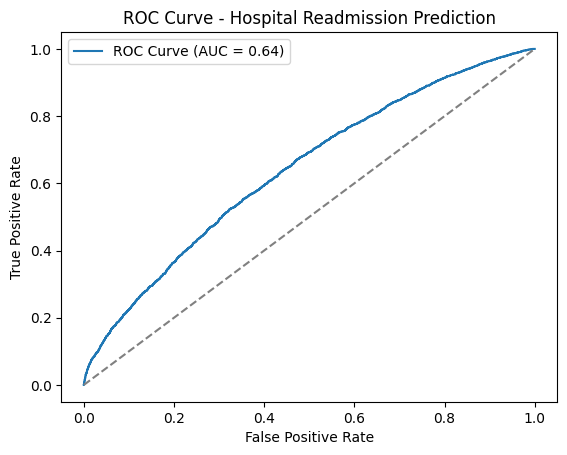


Discussion:
- False Negative (model says NO readmission, but patient DOES get readmitted within 30 days):
  This is the MORE dangerous error clinically. The patient misses out on extra 
  follow-up care, discharge planning, or monitoring, which can lead to worse 
  health outcomes, complications, or even death. It also costs the hospital 
  more in the long run (penalties, emergency readmission costs).

- False Positive (model says readmission risk is HIGH, but patient does NOT get readmitted):
  This is less risky since it just means the patient gets extra precautionary 
  care/follow-up which they didn't strictly need. It costs some extra resources 
  and hospital staff time, but no harm is done to the patient.

Conclusion: In this clinical setting, False Negatives are costlier than 
False Positives, so the model should be tuned (e.g., by adjusting the 
classification threshold) to prioritize higher Recall/Sensitivity, even if 
it means accepting more False Positives.



In [33]:
# Step 13: Plot ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Hospital Readmission Prediction')
plt.legend()
plt.show()

# ===== Discussion: Clinical Cost of False Negatives vs False Positives =====
print("""
Discussion:
- False Negative (model says NO readmission, but patient DOES get readmitted within 30 days):
  This is the MORE dangerous error clinically. The patient misses out on extra
  follow-up care, discharge planning, or monitoring, which can lead to worse
  health outcomes, complications, or even death. It also costs the hospital
  more in the long run (penalties, emergency readmission costs).

- False Positive (model says readmission risk is HIGH, but patient does NOT get readmitted):
  This is less risky since it just means the patient gets extra precautionary
  care/follow-up which they didn't strictly need. It costs some extra resources
  and hospital staff time, but no harm is done to the patient.

Conclusion: In this clinical setting, False Negatives are costlier than
False Positives, so the model should be tuned (e.g., by adjusting the
classification threshold) to prioritize higher Recall/Sensitivity, even if
it means accepting more False Positives.
""")